In [136]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("stefanoleone992/ea-sports-fc-24-complete-player-dataset")

print("Path to dataset files:", path)

#Ezt a kaggle oldaláról másoltam

Path to dataset files: /root/.cache/kagglehub/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset/versions/4


In [137]:
# Importok, későbbi használathoz

import pandas as pd
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
import scipy.io
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.nn as nn
import seaborn as sns


In [138]:
# A feladat megoldásához csak a férfi játékosokat fogjuk használni, ezért csak ezt olvassuk be

players = pd.read_csv(path + '/male_players.csv', low_memory=False)
players

,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,...,63+3,63+3,63+3,68+3,63+3,54+3,54+3,54+3,63+3,18+3
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,...,63+3,63+3,63+3,62+3,60+3,62+3,62+3,62+3,60+3,19+3
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,...,80+3,80+3,80+3,79+3,75+3,70+3,70+3,70+3,75+3,21+3
3,158023,/player/158023/lionel-messi/240002,24.0,2.0,2023-09-22,L. Messi,Lionel Andrés Messi Cuccittini,"CF, CAM",90,90,...,63+3,63+3,63+3,64+3,59+3,49+3,49+3,49+3,59+3,19+3
4,165153,/player/165153/karim-benzema/240002,24.0,2.0,2023-09-22,K. Benzema,Karim Benzema,"CF, ST",90,90,...,64+3,64+3,64+3,64+3,60+3,55+3,55+3,55+3,60+3,18+3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180016,220806,https://sofifa.com/player/220806/ellis-redman/...,15.0,2.0,2014-09-18,E. Redman,Ellis Redman,CB,41,61,...,38,38,38,37,40,41,41,41,40,10
180017,225509,https://sofifa.com/player/225509/aaron-collins...,15.0,2.0,2014-09-18,A. Collins,Aaron Graham John Collins,ST,41,50,...,30,30,30,31,32,31,31,31,32,14
180018,217591,https://sofifa.com/player/217591/piotr-zemlo/1...,15.0,2.0,2014-09-18,P. Żemło,Piotr Żemło,"LM, LB",40,50,...,46,46,46,48,51-1,53-3,53-3,53-3,51-1,12
180019,222947,https://sofifa.com/player/222947/tom-davies/15...,15.0,2.0,2014-09-18,T. Davies,Thomas Christopher Davies,CB,40,49,...,36,36,36,37,39,40,40,40,39,13


In [139]:
# Pozíciós adatok olyan formára hozása, hogy tudjak vele dolgozni

positions = ["ls", "st", "rs", "lw", "lf", "cf", "rf", "rw", "lam", "cam", "ram", "lm", "lcm", "cm", "rcm", "rm", "lwb", "ldm", "cdm", "rdm", "rwb", "lb", "lcb", "cb", "rcb", "rb", "gk"]
for pos in positions:
  players[pos] = players[pos].str.extract(r'(\d+)').astype(float)
  #print(players[pos])

#Játékos igazi pozíciójának kiválasztása
players['player_positions'] = players['player_positions'].str.split(', ')
players['player_positions'] = players['player_positions'].apply(lambda x: [pos.lower() for pos in x])

def get_real_position(row):
    max_position = None
    max_value = -float('inf')

    for pos in row['player_positions']:
        if pos in players.columns:
            if row[pos] > max_value:
                max_value = row[pos]
                max_position = pos

    return max_position

players['real_position'] = players.apply(get_real_position, axis=1)

#A pozíciók számformátumúvá alakítása
values, positions = pd.factorize(players['real_position'])
positions = list(positions)
players['real_position'] = values

In [140]:
#Feature-ök és label kiválasztása
'''
print(*list(players.columns), sep='\n')
[print(f'"{col}"', end=', ') for col in list(players.columns)]'''
players_used_for_training = players[(players['fifa_version'] != 24.0) & (players['fifa_version'] != 23.0)].copy()
players_used_for_generating = players[(players['fifa_version'] == 24.0) | (players['fifa_version'] == 23.0)].copy()
features = ["height_cm", "weight_kg", "weak_foot", "skill_moves", "pace", "shooting", "passing", "dribbling", "defending", "physic", "attacking_crossing", "attacking_finishing", "attacking_heading_accuracy", "attacking_short_passing", "attacking_volleys", "skill_dribbling", "skill_curve", "skill_fk_accuracy", "skill_long_passing", "skill_ball_control", "movement_acceleration", "movement_sprint_speed", "movement_agility", "movement_reactions", "movement_balance", "power_shot_power", "power_jumping", "power_stamina", "power_strength", "power_long_shots", "mentality_aggression", "mentality_interceptions", "mentality_positioning", "mentality_vision", "mentality_penalties", "mentality_composure", "defending_marking_awareness", "defending_standing_tackle", "defending_sliding_tackle", "goalkeeping_diving", "goalkeeping_handling", "goalkeeping_kicking", "goalkeeping_positioning", "goalkeeping_reflexes", "real_position"] + positions
target = 'overall'
x_labels = players_used_for_training[features].copy()
y_label = players_used_for_training[target].copy()
x_gen_labels = players_used_for_generating[features].copy()
y_gen_label = players_used_for_generating[target].copy()

In [7]:
x_labels

,height_cm,weight_kg,weak_foot,skill_moves,pace,shooting,passing,dribbling,defending,physic,...,gk,cdm,cb,rw,rb,lb,lm,rm,rwb,lwb
36883,170,72,4,4,85.0,92.0,91.0,95.0,34.0,65.0,...,19.0,64.0,50.0,92.0,61.0,61.0,91.0,91.0,66.0,66.0
36884,185,81,4,4,78.0,92.0,79.0,86.0,44.0,82.0,...,19.0,66.0,60.0,85.0,61.0,61.0,84.0,84.0,64.0,64.0
36885,182,73,4,5,97.0,88.0,80.0,92.0,36.0,77.0,...,18.0,63.0,54.0,90.0,63.0,63.0,89.0,89.0,67.0,67.0
36886,188,87,3,1,NaN,NaN,NaN,NaN,NaN,NaN,...,89.0,36.0,33.0,32.0,32.0,32.0,35.0,35.0,32.0,32.0
36887,187,83,4,5,87.0,94.0,80.0,88.0,34.0,75.0,...,20.0,59.0,53.0,88.0,60.0,60.0,86.0,86.0,63.0,63.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180016,187,81,2,2,66.0,25.0,29.0,30.0,39.0,53.0,...,10.0,38.0,41.0,33.0,40.0,40.0,34.0,34.0,37.0,37.0
180017,178,57,3,3,64.0,41.0,27.0,35.0,27.0,41.0,...,14.0,30.0,31.0,37.0,32.0,32.0,35.0,35.0,31.0,31.0
180018,190,76,3,2,58.0,27.0,35.0,31.0,52.0,68.0,...,12.0,46.0,53.0,38.0,51.0,51.0,40.0,40.0,48.0,48.0
180019,180,70,2,2,72.0,27.0,27.0,30.0,35.0,61.0,...,13.0,36.0,40.0,33.0,39.0,39.0,34.0,34.0,37.0,37.0


In [141]:
# Nan adatok helyettesítése
for feature in features:
  if x_labels[feature].isnull().sum() > 0:
    x_labels[feature].fillna(x_labels[feature].mean(), inplace=True)
  if x_gen_labels[feature].isnull().sum() > 0:
    x_gen_labels[feature].fillna(x_gen_labels[feature].mean(), inplace=True)

print(y_label.isnull().sum()) # A labelek esetén ez nem szükséges, mert mindenhol van érték

0


<ipython-input-141-ce1a487bb8b8>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_labels[feature].fillna(x_labels[feature].mean(), inplace=True)
<ipython-input-141-ce1a487bb8b8>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [10]:
x_labels.describe()

,height_cm,weight_kg,weak_foot,skill_moves,pace,shooting,passing,dribbling,defending,physic,...,gk,cdm,cb,rw,rb,lb,lm,rm,rwb,lwb
count,143138.000000,143138.000000,143138.000000,143138.000000,143138.000000,143138.000000,143138.000000,143138.000000,143138.000000,143138.000000,...,143138.000000,143138.000000,143138.000000,143138.000000,143138.000000,143138.000000,143138.000000,143138.000000,143138.000000,143138.000000
mean,181.199814,75.243276,2.938584,2.325343,67.983297,52.178455,56.866300,62.000236,51.026504,64.798562,...,21.146712,53.524110,52.299718,55.460975,53.239587,53.239587,56.181461,56.181461,53.919127,53.919127
std,6.735175,6.999078,0.661557,0.749038,10.481409,13.137524,9.954191,9.808441,15.749503,9.180428,...,15.336838,13.619573,14.660514,14.371854,13.779789,13.779789,13.897493,13.897493,13.481497,13.481497
min,154.000000,49.000000,1.000000,1.000000,21.000000,14.000000,20.000000,22.000000,14.000000,27.000000,...,4.000000,15.000000,15.000000,13.000000,14.000000,14.000000,15.000000,15.000000,14.000000,14.000000
25%,176.000000,70.000000,3.000000,2.000000,63.000000,44.000000,51.000000,57.000000,38.000000,60.000000,...,15.000000,46.000000,42.000000,49.000000,46.000000,46.000000,51.000000,51.000000,48.000000,48.000000
50%,181.000000,75.000000,3.000000,2.000000,67.983297,52.178455,56.866300,62.000236,52.000000,64.798562,...,16.000000,56.000000,55.000000,59.000000,56.000000,56.000000,59.000000,59.000000,56.000000,56.000000
75%,186.000000,80.000000,3.000000,3.000000,75.000000,62.000000,63.000000,68.000000,63.000000,71.000000,...,18.000000,64.000000,64.000000,65.000000,63.000000,63.000000,66.000000,66.000000,63.000000,63.000000
max,208.000000,110.000000,5.000000,5.000000,97.000000,94.000000,93.000000,96.000000,91.000000,92.000000,...,90.000000,87.000000,89.000000,93.000000,86.000000,86.000000,92.000000,92.000000,88.000000,88.000000


In [142]:
# Hasonló nagyságrendre hozás
scaler = StandardScaler()

x_labels = scaler.fit_transform(x_labels.values)
x_gen_labels = scaler.fit_transform(x_gen_labels.values)
y_label = y_label.to_numpy()
y_gen_label = y_gen_label.to_numpy()

In [143]:
# tanító, validációs és tesztelő adathazlmaz létrehozása

x_train, x_test, y_train, y_test = train_test_split(x_labels, y_label, test_size=0.3, random_state=13, shuffle=True)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5, random_state=13, shuffle=True)
x_gen_test,restx , y_gen_test, resty = train_test_split(x_gen_labels, y_gen_label, test_size=0.00000001, random_state=13, shuffle=True)

In [144]:
# Datasetek létrehozása

class PlayersDataset(Dataset):
    def __init__(self, features, target):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.target = torch.tensor(target, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.target[idx]

train_dataset = PlayersDataset(x_train, y_train)
val_dataset = PlayersDataset(x_val, y_val)
test_dataset = PlayersDataset(x_test, y_test)
generative_dataset = PlayersDataset(x_gen_test, y_gen_test)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True)
generative_dataloader = DataLoader(generative_dataset, batch_size=16, shuffle=True)


In [145]:
# Regressziós Modell definiálása


class RegressionModel(nn.Module):
  def __init__(self, input_dim):
        super().__init__()
        self.linear_relu_layers = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )

  def forward(self, x):
      return self.linear_relu_layers(x)

In [146]:
# Tanítás
n_epochs = 13
model = RegressionModel(x_labels.shape[1])
loss_fn = nn.MSELoss()

learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_losses = []
val_losses = []

for epoch in range(n_epochs):
  model.train()
  train_epoch_losses = []

  for x, y in train_dataloader:
    optimizer.zero_grad()
    y_hat = model(x)
    loss = loss_fn(y_hat, y)
    train_epoch_losses.append(loss)
    loss.backward()
    optimizer.step()

  train_epoch_losses = torch.tensor(train_epoch_losses)
  avg_epoch_loss = train_epoch_losses.mean()
  train_losses.append(avg_epoch_loss)

  model.eval()
  val_epoch_losses = []

  for x, y in val_dataloader:
    with torch.no_grad():
      y_hat = model(x)

    loss = loss_fn(y_hat, y)
    val_epoch_losses.append(loss)

  val_epoch_losses = torch.tensor(val_epoch_losses)
  avg_epoch_loss = val_epoch_losses.mean()
  val_losses.append(avg_epoch_loss)

  print(f'Tranining {epoch+1}/{n_epochs} done, training loss: {train_losses[-1]}, validation loss: {val_losses[-1]}')

Tranining 1/13 done, training loss: 352.6332092285156, validation loss: 10.492403984069824
Tranining 2/13 done, training loss: 4.034733772277832, validation loss: 2.2666521072387695
Tranining 3/13 done, training loss: 1.9802757501602173, validation loss: 1.730329990386963
Tranining 4/13 done, training loss: 1.6554561853408813, validation loss: 1.6394420862197876
Tranining 5/13 done, training loss: 1.5286767482757568, validation loss: 1.5641453266143799
Tranining 6/13 done, training loss: 1.4537720680236816, validation loss: 1.4380978345870972
Tranining 7/13 done, training loss: 1.3805557489395142, validation loss: 1.3009041547775269
Tranining 8/13 done, training loss: 1.3170442581176758, validation loss: 1.2370229959487915
Tranining 9/13 done, training loss: 1.2330961227416992, validation loss: 1.2312307357788086
Tranining 10/13 done, training loss: 1.1552082300186157, validation loss: 1.077796220779419
Tranining 11/13 done, training loss: 1.0977429151535034, validation loss: 1.0271769

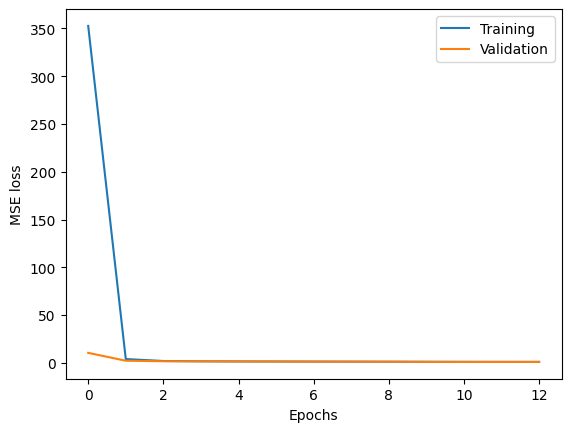

In [147]:
# Hiba vizualizálása

plt.plot(train_losses, label='Training')
plt.plot(val_losses, label='Validation')
plt.xlabel('Epochs')
plt.ylabel('MSE loss')
plt.legend()
plt.show()

In [148]:
# Kiértékelés

model.eval()
test_losses = []
prediction_label_pairs = []
for x, y in test_dataloader:
    with torch.no_grad():
      y_hat = torch.round(model(x))
    loss = loss_fn(y_hat, y)
    prediction_label_pairs.append(torch.concat((y_hat, y), dim=-1))
    test_losses.append(loss)

avg_test_loss = torch.tensor(test_losses).mean()
print('Average loss on the test dataset: ', avg_test_loss.item())
print(prediction_label_pairs[0])

Average loss on the test dataset:  1.1541355848312378
tensor([[85., 84.],
        [74., 73.],
        [76., 75.],
        [51., 51.],
        [65., 65.],
        [61., 61.],
        [52., 51.],
        [53., 53.],
        [55., 56.],
        [67., 67.],
        [60., 60.],
        [69., 67.],
        [61., 60.],
        [70., 70.],
        [75., 75.],
        [51., 51.]])


In [150]:
# Új Fifa játékok adatainak generálása a modell segítségével, pontosság

model.eval()
test_losses = []
prediction_label_pairs = []
for x, y in generative_dataloader:
    with torch.no_grad():
      y_hat = torch.round(model(x))
    loss = loss_fn(y_hat, y)
    prediction_label_pairs.append(torch.concat((y_hat, y), dim=-1))
    test_losses.append(loss)

avg_test_loss = torch.tensor(test_losses).mean()
print('Average loss on the test dataset: ', avg_test_loss.item())
print(prediction_label_pairs[0])

print("Example Usage:")
values_23 = players[(players['short_name'] == 'L. Messi') & (players['fifa_version'] == 23.0)][features].values
values_24 = players[(players['short_name'] == 'L. Messi') & (players['fifa_version'] == 23.0)][features].values
values_23 = (values_23 - scaler.mean_) / scaler.scale_
values_24 = (values_24 - scaler.mean_) / scaler.scale_
Messi_eval_23 = torch.round(model(torch.tensor(values_23, dtype=torch.float32)))
Messi_eval_24 = torch.round(model(torch.tensor(values_24, dtype=torch.float32)))
print(f"Lionel Messi Fifa 23 value: {players[(players['short_name'] == 'L. Messi') & (players['fifa_version'] == 23.0)][target].values[0]}, predicted value: {Messi_eval_23.item()}")
print(f"Lionel Messi Fifa 24 value: {players[(players['short_name'] == 'L. Messi') & (players['fifa_version'] == 24.0)][target].values[0]}, predicted value: {Messi_eval_24.item()}")

Average loss on the test dataset:  1.1706689596176147
tensor([[67., 68.],
        [69., 68.],
        [68., 67.],
        [66., 67.],
        [72., 71.],
        [68., 67.],
        [60., 61.],
        [62., 61.],
        [62., 61.],
        [57., 57.],
        [68., 67.],
        [58., 57.],
        [53., 54.],
        [68., 67.],
        [62., 61.],
        [66., 68.]])
Example Usage:
Lionel Messi Fifa 23 value: 91, predicted value: 90.0
Lionel Messi Fifa 24 value: 90, predicted value: 90.0


In [151]:
#Ugyan ez Multi klassz klasszifikációval

class MCClassificationModel(nn.Module):
  def __init__(self, input_dim, n_class):
        super().__init__()
        self.linear_relu_layers = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(8,n_class)
        )

  def forward(self, x):
      out = self.linear_relu_layers(x)
      return out

In [152]:
classes = np.unique([x for x in range(1,100)])
n_class = classes.shape[0]
print(classes)
targets = players_used_for_training['overall'].values.copy()
targets = np.eye(n_class)[targets - 1]


x_train, x_rest, y_train, y_rest = train_test_split(x_labels, targets, train_size=0.7, random_state=13)
x_val, x_test, y_val, y_test = train_test_split(x_rest, y_rest, train_size=0.5, random_state=13)

x_train_min = np.min(x_train, axis=0)
x_train_max = np.max(x_train, axis=0)

x_train = (x_train - x_train_min) / (x_train_max - x_train_min)
x_val = (x_val - x_train_min) / (x_train_max - x_train_min)
x_test = (x_test - x_train_min) / (x_train_max - x_train_min)

class Players2Dataset(Dataset):
    def __init__(self, features, target):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.target = torch.tensor(target, dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.target[idx]

train_dataset = Players2Dataset(x_train, y_train)
val_dataset = Players2Dataset(x_val, y_val)
test_dataset = Players2Dataset(x_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True)


print(train_dataset[11])

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
 97 98 99]
(tensor([0.2778, 0.2951, 0.7500, 0.2500, 0.7600, 0.5696, 0.6575, 0.6351, 0.6753,
        0.6000, 0.7386, 0.5161, 0.6593, 0.7093, 0.4831, 0.6842, 0.5955, 0.7609,
        0.6778, 0.7143, 0.7674, 0.7791, 0.7412, 0.6053, 0.7816, 0.7283, 0.7262,
        0.8046, 0.4884, 0.7473, 0.8085, 0.6889, 0.5532, 0.7097, 0.7363, 0.5801,
        0.7097, 0.7111, 0.7065, 0.0778, 0.0549, 0.0957, 0.1429, 0.1429, 0.6429,
        0.6962, 0.6154, 0.7123, 0.6582, 0.6456, 0.1163, 0.7361, 0.7027, 0.6962,
        0.7639, 0.7639, 0.7105, 0.7105, 0.7432, 0.7432]), tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

In [153]:
class Callback():
  def __init__(self):
    pass

  def on_train_end(self, avg_train_loss):
    pass

  def on_val_end(self, avg_val_loss):
    pass

  def on_test_end(self, avg_test_loss):
    pass

  def on_epoch_end(self, trainer):
    pass

  def on_train_prediction(self, prediction, label):
    pass

  def on_val_prediction(self, prediction, label):
    pass

  def on_test_prediction(self, prediction, label):
    pass

  def on_stop(self, results):
    pass

class EarlyStoppingCallback(Callback):
  def __init__(self, delta=0.01, patience=10, save_path=None, model=None):
    self.delta = delta
    self.patience = patience
    self.best_loss = np.inf
    self.no_improvement_count = 0
    self.save_path = save_path
    self.model = model

  def on_val_end(self, avg_val_loss):
    if avg_val_loss + self.delta < self.best_loss:
      self.best_loss = avg_val_loss
      self.no_improvement_count = 0
      if self.save_path is not None and self.model is not None:
        torch.save(self.model.state_dict(), self.save_path)
    else:
      self.no_improvement_count += 1

  def on_epoch_end(self, trainer):
    if self.no_improvement_count >= self.patience:
      print('Stopped by early stopping.')
      print('Best validation loss: ', self.best_loss.item())
      trainer.stop = True

class MetricsCallback(Callback):
  def __init__(self, metrics_to_track):
    self.metrics_to_track = metrics_to_track
    self.__reset()

  def __reset(self):
    self.metrics_temp = dict()
    self.metrics = dict()

  def __add_prediction(self, prediction, label, prefix):
    for metric_name, metric_fn in self.metrics_to_track.items():
      key = f'{prefix}_{metric_name}'
      if key not in self.metrics:
        self.metrics[key] = []
        self.metrics_temp[key] = []

      self.metrics_temp[key].append(metric_fn(prediction, label).reshape(-1))

  def __aggregate_metrics(self, prefix):
    for key in self.metrics_to_track.keys():
      self.metrics[f'{prefix}_{key}'].append(torch.cat(self.metrics_temp[f'{prefix}_{key}']).mean().item())
      self.metrics_temp[f'{prefix}_{key}'] = []

  def on_train_prediction(self, prediction, label):
    self.__add_prediction(prediction, label, 'train')

  def on_val_prediction(self, prediction, label):
    self.__add_prediction(prediction, label, 'val')

  def on_test_prediction(self, prediction, label):
    self.__add_prediction(prediction, label, 'test')

  def on_train_end(self, avg_train_loss):
    self.__aggregate_metrics('train')

  def on_val_end(self, avg_val_loss):
    self.__aggregate_metrics('val')

  def on_test_end(self, avg_test_loss):
    self.__aggregate_metrics('test')

  def on_stop(self, results):
    metrics = {key: np.array(val) for key,val in self.metrics.items()}
    results.update(metrics)
    self.__reset()

class Trainer():
  def __init__(self, model, train_dataloader, val_dataloader, optimizer, loss_fn, n_epochs=10, callbacks=[]):
    self.model = model
    self.train_dataloader = train_dataloader
    self.val_dataloader = val_dataloader
    self.optimizer = optimizer
    self.loss_fn = loss_fn
    self.n_epochs = n_epochs
    self.stop = False
    self.callbacks = callbacks
    self.train_losses = []
    self.val_losses = []

  def __train(self, dataloader):
    self.model.train()
    train_epoch_losses = []

    for x, y in dataloader:
      self.optimizer.zero_grad()
      y_hat = self.model(x)
      loss = self.loss_fn(y_hat, y)
      [callback.on_train_prediction(y_hat.detach(), y) for callback in self.callbacks]
      train_epoch_losses.append(loss)
      loss.backward()
      self.optimizer.step()

    train_epoch_losses = torch.tensor(train_epoch_losses)
    avg_epoch_loss = train_epoch_losses.mean()

    [callback.on_train_end(avg_epoch_loss) for callback in self.callbacks]

    return avg_epoch_loss

  def __eval(self, dataloader, test=False):
    self.model.eval()
    epoch_losses = []

    for x, y in dataloader:
      with torch.no_grad():
        y_hat = self.model(x)

      loss = self.loss_fn(y_hat, y)
      if test:
        [callback.on_test_prediction(y_hat.detach(), y) for callback in self.callbacks]
      else:
        [callback.on_val_prediction(y_hat.detach(), y) for callback in self.callbacks]

      epoch_losses.append(loss)

    epoch_losses = torch.tensor(epoch_losses)
    avg_epoch_loss = epoch_losses.mean()

    if test:
      [callback.on_test_end(avg_epoch_loss) for callback in self.callbacks]
    else:
      [callback.on_val_end(avg_epoch_loss) for callback in self.callbacks]

    return avg_epoch_loss

  def train(self):
    for epoch in range(self.n_epochs):
      train_loss = self.__train(self.train_dataloader)
      self.train_losses.append(train_loss)
      val_loss = self.__eval(self.val_dataloader, test=False)
      self.val_losses.append(val_loss)

      print(f'Tranining {epoch+1}/{self.n_epochs} done, training loss: {train_loss}, validation loss: {val_loss}')

      [callback.on_epoch_end(self) for callback in self.callbacks]

      if self.stop:
        break

    results = {
        'train_loss': self.train_losses,
        'val_loss': self.val_losses
    }

    [callback.on_stop(results) for callback in self.callbacks]

    return results

  def test(self, test_dataloader):
    test_loss = self.__eval(test_dataloader, test=True)

    results = {
        'test_loss': test_loss
    }

    [callback.on_stop(results) for callback in self.callbacks]

    return results

In [154]:
model = MCClassificationModel(train_dataset[0][0].shape[0], n_class=n_class)
loss_fn = nn.CrossEntropyLoss()

learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

def accuracy(pred, label):
  pred = torch.argmax(pred, dim=-1)
  label = torch.argmax(label, dim=-1)

  return (pred == label).to(torch.float32)

metrics = {
    'Accuracy': accuracy
}

earlystopping_callback = EarlyStoppingCallback(delta=0.1, patience=10, save_path='best_model.pth')
metrics_callback = MetricsCallback(metrics)
callbacks = [earlystopping_callback, metrics_callback]
trainer = Trainer(model, train_dataloader, val_dataloader, optimizer, loss_fn, n_epochs=400, callbacks=callbacks)
results = trainer.train()

Tranining 1/400 done, training loss: 3.213784694671631, validation loss: 2.7178261280059814
Tranining 2/400 done, training loss: 2.7310380935668945, validation loss: 2.469733476638794
Tranining 3/400 done, training loss: 2.586174249649048, validation loss: 2.295588493347168
Tranining 4/400 done, training loss: 2.512005090713501, validation loss: 2.3361852169036865
Tranining 5/400 done, training loss: 2.4670157432556152, validation loss: 2.196730852127075
Tranining 6/400 done, training loss: 2.4531633853912354, validation loss: 2.270838499069214
Tranining 7/400 done, training loss: 2.427924394607544, validation loss: 2.182971239089966
Tranining 8/400 done, training loss: 2.420031785964966, validation loss: 2.187195062637329
Tranining 9/400 done, training loss: 2.408479690551758, validation loss: 2.1320743560791016
Tranining 10/400 done, training loss: 2.4005353450775146, validation loss: 2.1827688217163086
Tranining 11/400 done, training loss: 2.390965461730957, validation loss: 2.17730

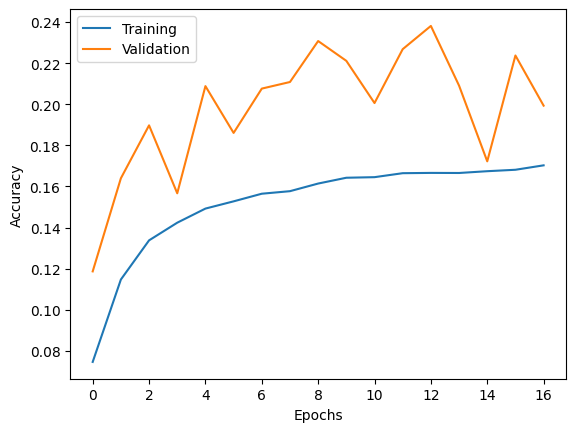

In [155]:
plt.plot(results['train_Accuracy'], label='Training')
plt.plot(results['val_Accuracy'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [156]:
model.eval()
accuracy = []
prediction_label_pairs = []
for x, y in test_dataloader:
    with torch.no_grad():
      y_hat = model(x)
    prediction = torch.argmax(y_hat, dim=1)
    y = torch.argmax(y, dim=1)
    prediction_label_pairs.append(torch.stack((prediction, y), dim=-1))
    accuracy.append((prediction == y).to(torch.float32))

accuracy = torch.cat(accuracy).mean()
print('Accuracy: ', accuracy.item())
print(prediction_label_pairs[0])

print(trainer.test(test_dataloader))

Accuracy:  0.20450840890407562
tensor([[55, 52],
        [65, 64],
        [69, 70],
        [73, 75],
        [65, 65],
        [65, 67],
        [68, 68],
        [55, 58],
        [73, 77],
        [57, 57],
        [57, 53],
        [65, 65],
        [65, 68],
        [69, 70],
        [65, 65],
        [68, 69]])
{'test_loss': tensor(2.1533), 'test_Accuracy': array([0.20450841])}


In [158]:
print("Example Usage:")
values_23 = players[(players['short_name'] == 'L. Messi') & (players['fifa_version'] == 23.0)][features].values
values_24 = players[(players['short_name'] == 'L. Messi') & (players['fifa_version'] == 23.0)][features].values
values_23 = (values_23 - scaler.mean_) / scaler.scale_
values_24 = (values_24 - scaler.mean_) / scaler.scale_
Messi_eval_23 = torch.argmax(model(torch.tensor(values_23, dtype=torch.float32)), dim=1)
Messi_eval_24 = torch.argmax(model(torch.tensor(values_24, dtype=torch.float32)), dim=1)
print(f"Lionel Messi Fifa 23 value: {players[(players['short_name'] == 'L. Messi') & (players['fifa_version'] == 23.0)]['overall'].values[0]}, predicted value: {Messi_eval_23.item()}")
print(f"Lionel Messi Fifa 24 value: {players[(players['short_name'] == 'L. Messi') & (players['fifa_version'] == 24.0)]['overall'].values[0]}, predicted value: {Messi_eval_24.item()}")

Example Usage:
Lionel Messi Fifa 23 value: 91, predicted value: 82
Lionel Messi Fifa 24 value: 90, predicted value: 82


Konvolúciós Neuronháló

In [170]:
class CNN1DModell(nn.Module):
    def __init__(self, n_features, n_class):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.MaxPool1d(kernel_size=2)
        )
        self.layer2 = nn.Flatten()
        self.layer3 = nn.Sequential(
            nn.Linear(64 * ((n_features - 3 + 1) // 2), 100),
            nn.ReLU()
        )
        self.layer4 = nn.Sequential(
            nn.Linear(100, 1),
        )

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        return out

In [167]:
x_train, x_test, y_train, y_test = train_test_split(x_labels, y_label, test_size=0.3, random_state=13, shuffle=True)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5, random_state=13, shuffle=True)
x_gen_test,restx , y_gen_test, resty = train_test_split(x_gen_labels, y_gen_label, test_size=0.00000001, random_state=13, shuffle=True)

class Players3Dataset(Dataset):
    def __init__(self, features, target):
        self.features = torch.tensor(features, dtype=torch.float32).unsqueeze(1)
        self.target = torch.tensor(target, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.target[idx]

train_dataset = Players3Dataset(x_train, y_train)
val_dataset = Players3Dataset(x_val, y_val)
test_dataset = Players3Dataset(x_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True)


print(train_dataset[11])

(tensor([[-1.8114, -1.1778,  1.6044, -0.4343,  0.9557,  0.5192,  1.1185,  0.7136,
          0.9507,  0.1309,  1.1274,  0.2327,  0.6836,  0.6600,  0.1666,  0.6387,
          0.5936,  1.7345,  0.8837,  0.7141,  0.8388,  0.9107,  0.7251,  0.4796,
          1.0075,  0.8485,  0.7628,  1.0720, -0.8845,  1.2551,  1.2914,  0.9064,
          0.2129,  1.1194,  1.4865,  0.0000,  1.0437,  0.9090,  1.0667, -0.4833,
         -0.6116, -0.3739, -0.1353, -0.1477,  0.8781,  0.8725,  0.5642,  0.9277,
          0.7518,  0.6976, -0.4660,  1.0629,  1.0027,  0.8725,  1.1437,  1.1437,
          0.9224,  0.9224,  1.1186,  1.1186]]), tensor([69.]))


In [171]:
# Tanítás
n_epochs = 10
model = CNN1DModell(x_labels.shape[1],99)
loss_fn = nn.MSELoss()

learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_losses = []
val_losses = []

for epoch in range(n_epochs):
  model.train()
  train_epoch_losses = []

  for x, y in train_dataloader:
    optimizer.zero_grad()
    y_hat = model(x)
    loss = loss_fn(y_hat, y)
    train_epoch_losses.append(loss)
    loss.backward()
    optimizer.step()

  train_epoch_losses = torch.tensor(train_epoch_losses)
  avg_epoch_loss = train_epoch_losses.mean()
  train_losses.append(avg_epoch_loss)

  model.eval()
  val_epoch_losses = []

  for x, y in val_dataloader:
    with torch.no_grad():
      y_hat = model(x)

    loss = loss_fn(y_hat, y)
    val_epoch_losses.append(loss)

  val_epoch_losses = torch.tensor(val_epoch_losses)
  avg_epoch_loss = val_epoch_losses.mean()
  val_losses.append(avg_epoch_loss)

  print(f'Tranining {epoch+1}/{n_epochs} done, training loss: {train_losses[-1]}, validation loss: {val_losses[-1]}')

Tranining 1/10 done, training loss: 13.558645248413086, validation loss: 238.76953125
Tranining 2/10 done, training loss: 4.737425327301025, validation loss: 292.0550842285156
Tranining 3/10 done, training loss: 4.184782981872559, validation loss: 318.07757568359375
Tranining 4/10 done, training loss: 3.9031901359558105, validation loss: 350.489013671875
Tranining 5/10 done, training loss: 3.766937494277954, validation loss: 374.1649475097656
Tranining 6/10 done, training loss: 3.5617079734802246, validation loss: 331.9673156738281
Tranining 7/10 done, training loss: 3.448899745941162, validation loss: 370.1406555175781
Tranining 8/10 done, training loss: 3.375309467315674, validation loss: 317.6941223144531
Tranining 9/10 done, training loss: 3.2942323684692383, validation loss: 329.56158447265625
Tranining 10/10 done, training loss: 3.2602245807647705, validation loss: 326.1313781738281


In [172]:
# Kiértékelés

model.eval()
test_losses = []
prediction_label_pairs = []
for x, y in test_dataloader:
    with torch.no_grad():
      y_hat = torch.round(model(x))
    loss = loss_fn(y_hat, y)
    prediction_label_pairs.append(torch.concat((y_hat, y), dim=-1))
    test_losses.append(loss)

avg_test_loss = torch.tensor(test_losses).mean()
print('Average loss on the test dataset: ', avg_test_loss.item())
print(prediction_label_pairs[0])

Average loss on the test dataset:  324.9850158691406
tensor([[51., 71.],
        [53., 74.],
        [47., 65.],
        [56., 73.],
        [55., 72.],
        [46., 60.],
        [48., 67.],
        [51., 70.],
        [55., 76.],
        [45., 60.],
        [48., 67.],
        [54., 74.],
        [44., 58.],
        [56., 74.],
        [50., 69.],
        [54., 76.]])
